# EDA: Gait Metrics & Clinical Outcomes

Explore relationships between wrist-sensor gait metrics and clinical outcomes.  
**Feature buckets:**
1. **Gait bout metrics** — bout-level speed, cadence, stride length, duration, etc.
2. **Daily PA variables** — daily walking time, step counts, activity epochs (from full recordings, not gait bouts)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
pd.set_option('display.max_columns', 50)

df = pd.read_csv('output/merged_gait_clinical_abl.csv')
print(f'Dataset: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Unique subjects: {df["projid"].nunique()}')

Dataset: 790 rows, 381 columns
Unique subjects: 790


## 1. Define feature buckets and outcomes

In [13]:
# Feature buckets
id_cols = ['sub_id', 'projid', 'fu_year', 'wear_days', 'study']
daily_pa_cols = [c for c in df.columns
                 if c.startswith('daily_pa_mean_') or c.startswith('daily_pa_std_') or c.startswith('tdpa_')]

# Exclude all outcome / clinical / demographic columns from gait features
exclude_from_gait = set(id_cols + daily_pa_cols + [
    'age_bl', 'msex', 'educ', 'race7', 'study', 'device', 'age_at_visit',
    'parkinsonism_yn', 'dcfdx', 'dementia', 'cpd_ever', 'cogdx',
    'rosbsum', 'falls', 'falls_binary', 'mobility_disability_binary',
    'cognitive_impairment',
    'cogn_global', 'cogn_ep', 'cogn_po', 'cogn_ps', 'cogn_se', 'cogn_wo',
    'cogng_demog_slope', 'time_lastce2dod', 'age_death',
    'cts_mmse30', 'parksc', 'motor10', 'gait_speed', 'scaled_to',
    'pert_noact_avg', 'tactivity_acth_avgnew', 'tactivity_d_avgnew',
    'r_depres', 'bmi', 'med_con_sum_cum', 'vasc_risks_sum',
    'iadlsum', 'katzsum', 'late_life_cogact_freq', 'phys5itemsum',
    'late_life_soc_act', 'park_rx',
    'motor10_demog_slope', 'sqrt_parksc_demog_slope',
    'motor_dexterity', 'motor_gait', 'motor_handstreng',
    'is', 'iv', 'kar', 'kra', 'bradysc','gaitsc', 'rigidsc', 'tremsc'
])
gait_bout_cols = [c for c in df.columns if c not in exclude_from_gait
                  and not c.startswith('daily_pa_mean_')
                  and not c.startswith('daily_pa_std_')
                  and not c.startswith('tdpa_')]

# Outcomes
binary_outcomes = {
    'parkinsonism_yn': 'Parkinsonism (Y/N)',
    'mobility_disability_binary': 'Mobility Disability (rosbsum>0)',
    'falls_binary': 'Falls (Y/N)',
    'cognitive_impairment': 'Cognitive Impairment (NCI vs impaired)',
}
continuous_outcomes = {
    'parksc': 'Parkinsonism Score',
    'motor10': 'Motor Composite (motor10)',
    'cogn_global': 'Global Cognition',
}
multiclass_outcomes = {
    'rosbsum': 'Rosow-Breslau (mobility disability)',
    'falls': 'Number of falls',
    'dcfdx': 'Clinical diagnosis (dcfdx)',
}

print(f'Daily PA features: {len(daily_pa_cols)}')
print(f'Gait bout features: {len(gait_bout_cols)}')

Daily PA features: 30
Gait bout features: 290


## 2. Missingness overview

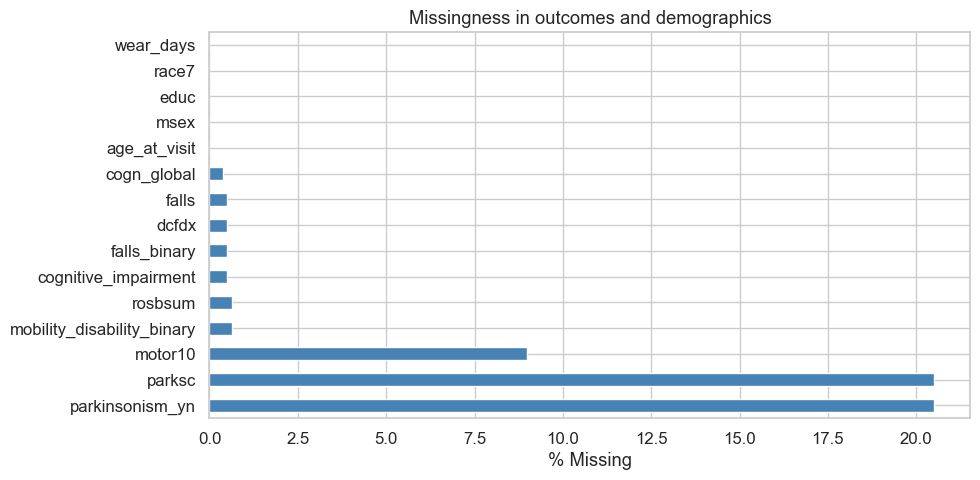

In [15]:
# Missingness for outcomes and demographics
check_cols = list(binary_outcomes.keys()) + list(continuous_outcomes.keys()) + \
             list(multiclass_outcomes.keys()) + ['age_at_visit', 'msex', 'educ', 'race7', 'wear_days']
miss = df[check_cols].isnull().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 5))
miss.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('% Missing')
ax.set_title('Missingness in outcomes and demographics')
plt.tight_layout()
plt.show()

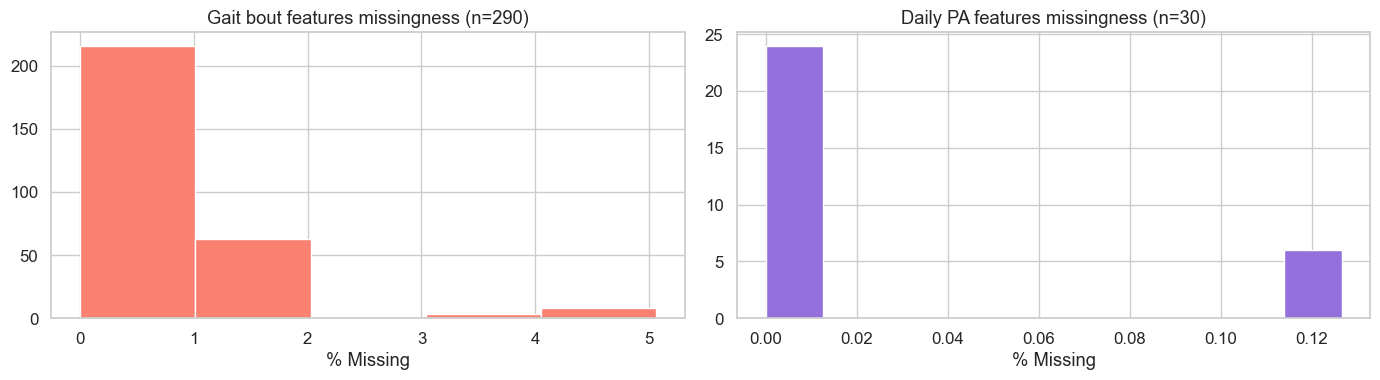

Gait bout features with >50% missing: 0
Daily PA features with >50% missing: 0


In [18]:
# Missingness in feature buckets
gait_miss = df[gait_bout_cols].isnull().mean() * 100
pa_miss = df[daily_pa_cols].isnull().mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(gait_miss, bins=5, color='salmon', edgecolor='white')
axes[0].set_title(f'Gait bout features missingness (n={len(gait_bout_cols)})')
axes[0].set_xlabel('% Missing')
axes[1].hist(pa_miss, bins=10, color='mediumpurple', edgecolor='white')
axes[1].set_title(f'Daily PA features missingness (n={len(daily_pa_cols)})')
axes[1].set_xlabel('% Missing')
plt.tight_layout()
plt.show()

print('Gait bout features with >50% missing:', (gait_miss > 50).sum())
print('Daily PA features with >50% missing:', (pa_miss > 50).sum())

## 3. Demographics overview

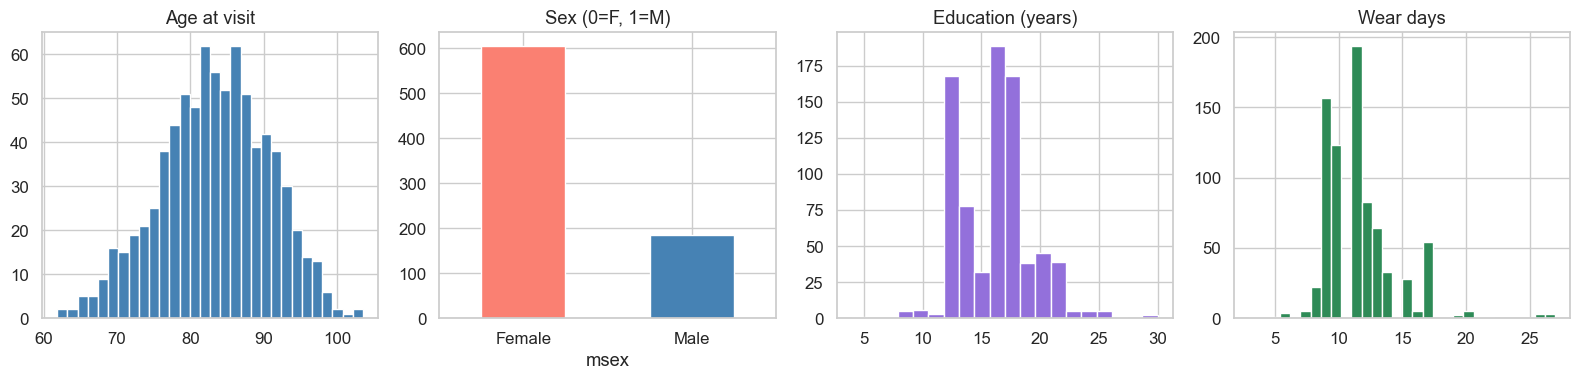

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

df['age_at_visit'].dropna().hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Age at visit')

df['msex'].dropna().value_counts().plot.bar(ax=axes[1], color=['salmon', 'steelblue'])
axes[1].set_title('Sex (0=F, 1=M)')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)

df['educ'].dropna().hist(bins=20, ax=axes[2], color='mediumpurple', edgecolor='white')
axes[2].set_title('Education (years)')

df['wear_days'].hist(bins=30, ax=axes[3], color='seagreen', edgecolor='white')
axes[3].set_title('Wear days')

plt.tight_layout()
plt.show()

## 4. Outcome distributions

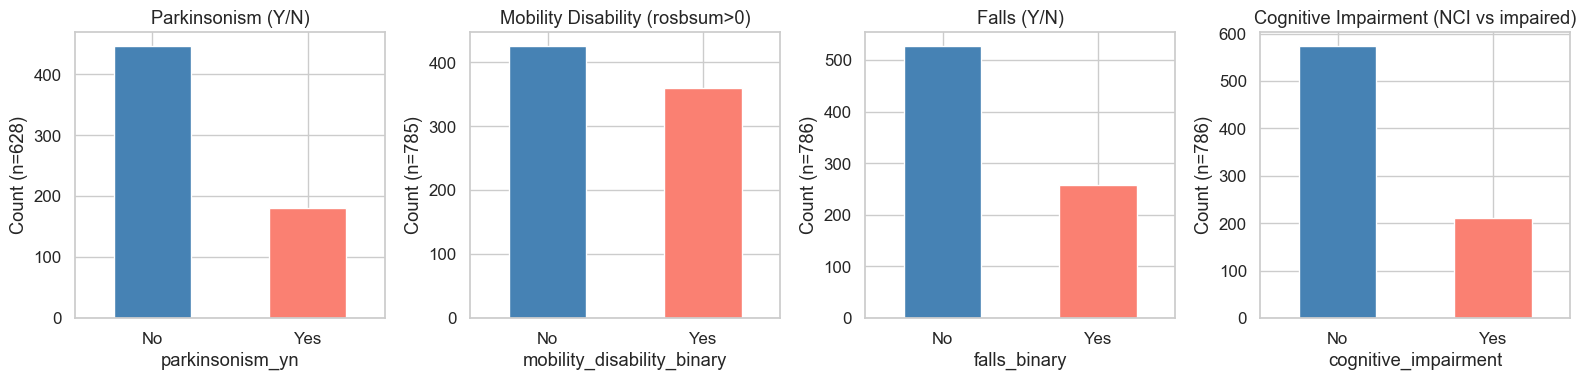

In [20]:
# Binary outcomes
fig, axes = plt.subplots(1, len(binary_outcomes), figsize=(16, 4))
for ax, (col, label) in zip(axes, binary_outcomes.items()):
    vc = df[col].dropna().value_counts().sort_index()
    vc.plot.bar(ax=ax, color=['steelblue', 'salmon'])
    ax.set_title(label)
    ax.set_xticklabels(['No', 'Yes'], rotation=0)
    n = df[col].notna().sum()
    ax.set_ylabel(f'Count (n={n})')
plt.tight_layout()
plt.show()

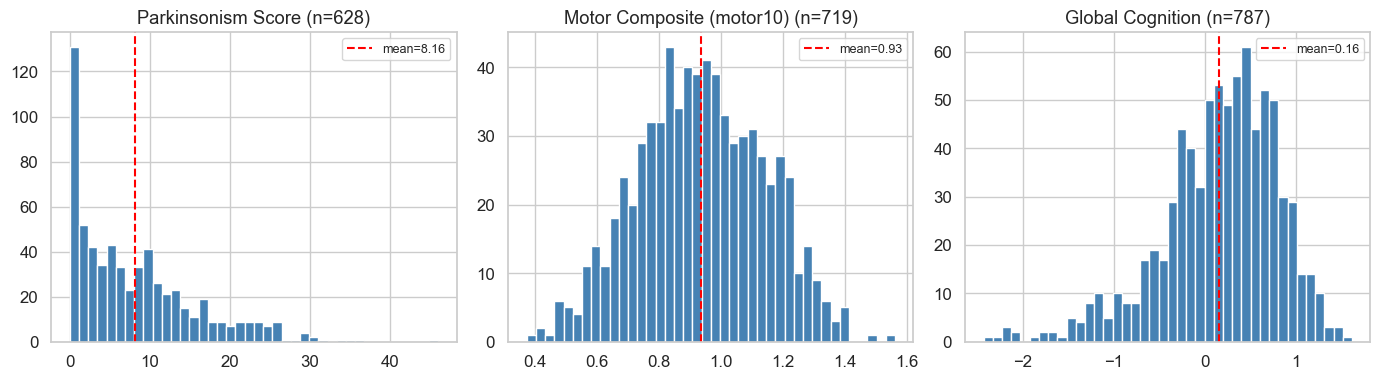

In [21]:
# Continuous outcomes
fig, axes = plt.subplots(1, len(continuous_outcomes), figsize=(14, 4))
for ax, (col, label) in zip(axes, continuous_outcomes.items()):
    vals = df[col].dropna()
    vals.hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{label} (n={len(vals)})')
    ax.axvline(vals.mean(), color='red', ls='--', label=f'mean={vals.mean():.2f}')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

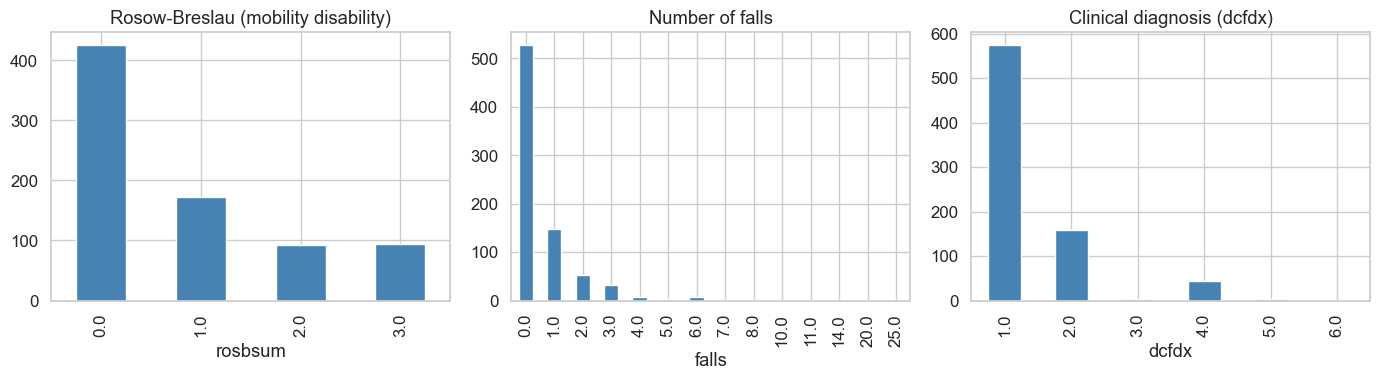

In [22]:
# Multi-class outcomes
fig, axes = plt.subplots(1, len(multiclass_outcomes), figsize=(14, 4))
for ax, (col, label) in zip(axes, multiclass_outcomes.items()):
    vc = df[col].dropna().value_counts().sort_index()
    vc.plot.bar(ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

## 5. Gait bout metrics: distribution of key features

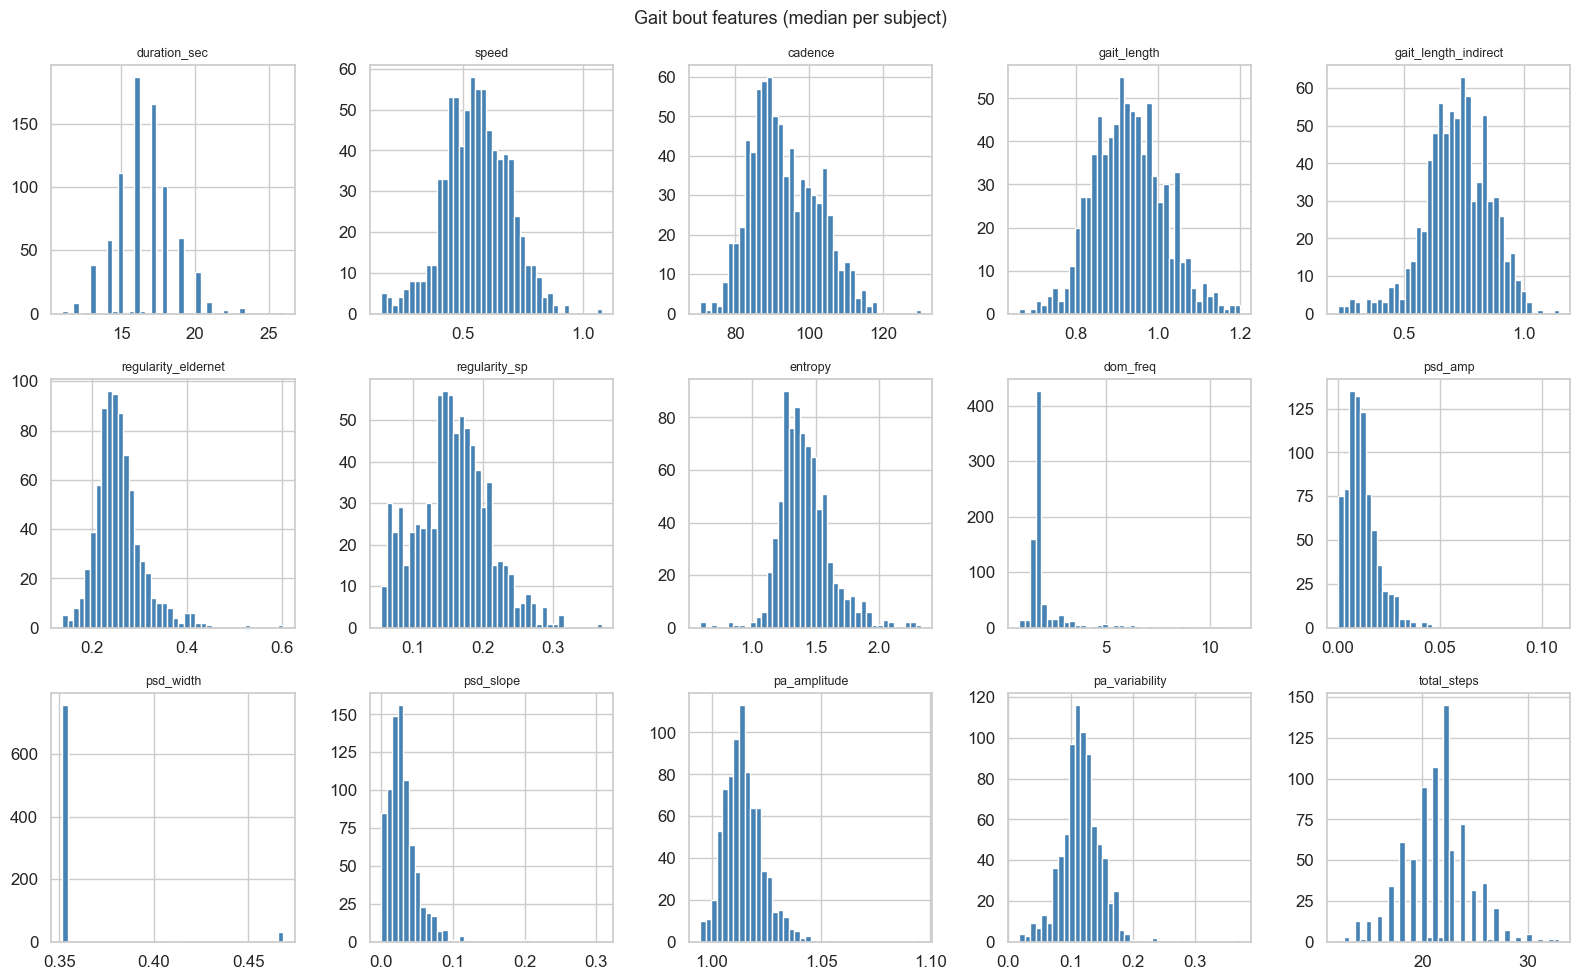

In [28]:
# Show distributions of median-level gait bout features
key_gait = [c for c in gait_bout_cols if c.endswith('_median') and 'bout_' in c]
n_plots = min(len(key_gait), 15)
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
for i, ax in enumerate(axes.flat):
    if i < n_plots:
        vals = df[key_gait[i]].dropna()
        ax.hist(vals, bins=40, color='steelblue', edgecolor='white')
        ax.set_title(key_gait[i].replace('bout_', '').replace('_median', ''), fontsize=9)
    else:
        ax.axis('off')
plt.suptitle('Gait bout features (median per subject)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Daily PA variables: distribution of key features

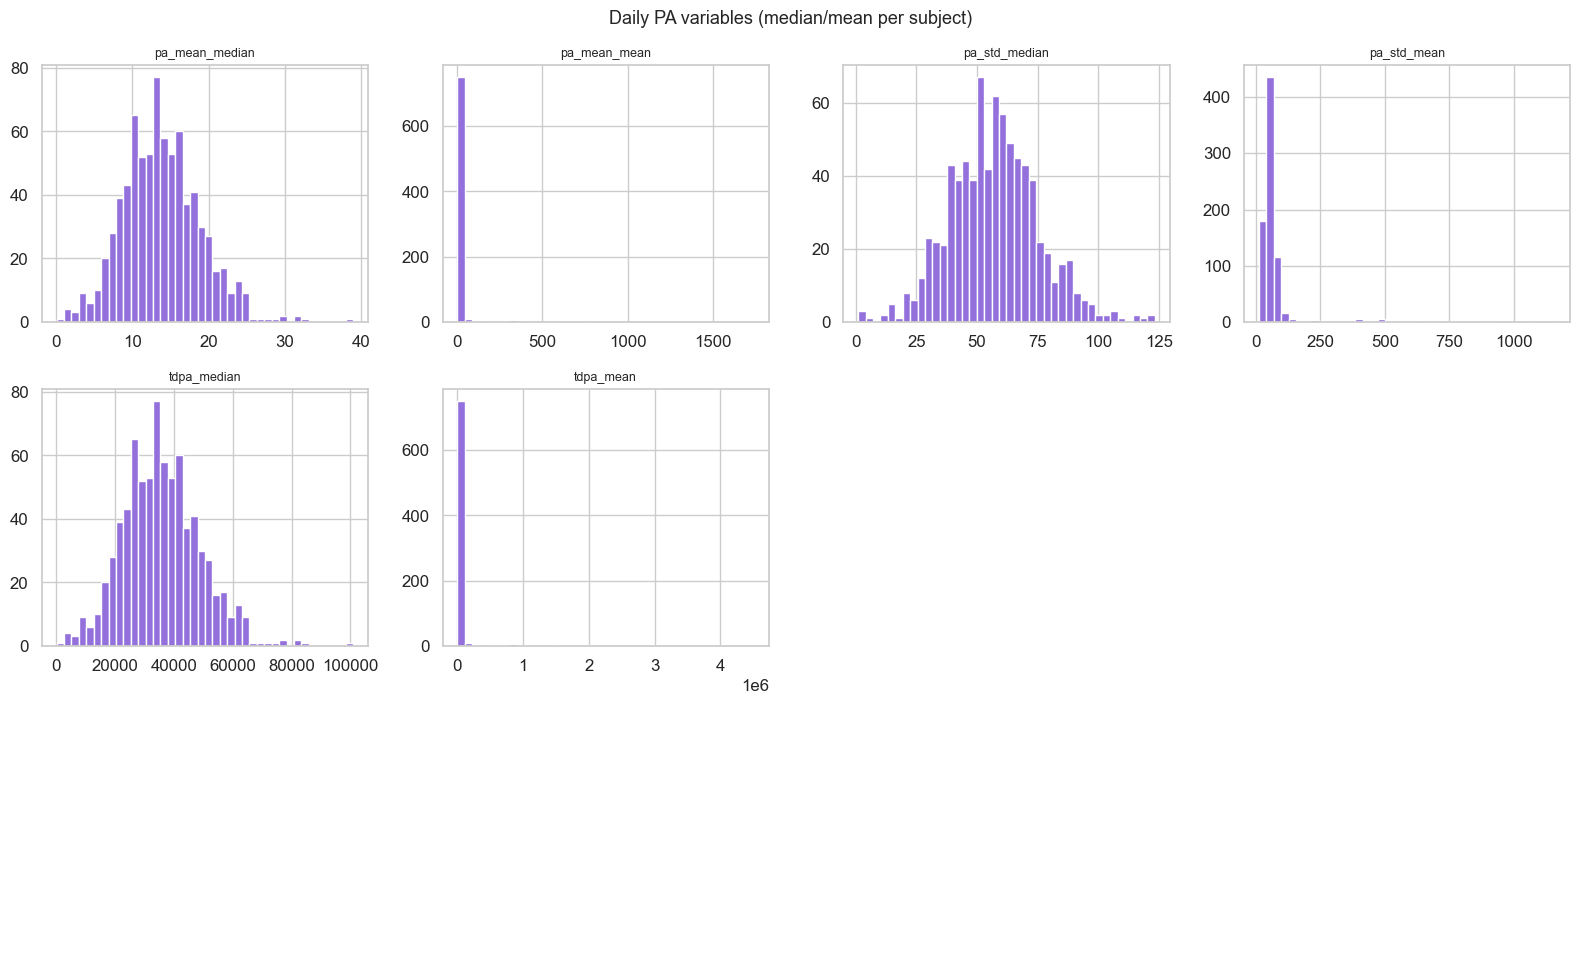

In [29]:
key_pa = [c for c in daily_pa_cols if c.endswith('_median') or c.endswith('_mean')]
n_plots = min(len(key_pa), 12)
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i, ax in enumerate(axes.flat):
    if i < n_plots:
        vals = df[key_pa[i]].dropna()
        ax.hist(vals, bins=40, color='mediumpurple', edgecolor='white')
        ax.set_title(key_pa[i].replace('daily_', ''), fontsize=9)
    else:
        ax.axis('off')
plt.suptitle('Daily PA variables (median/mean per subject)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Correlation structure within feature buckets

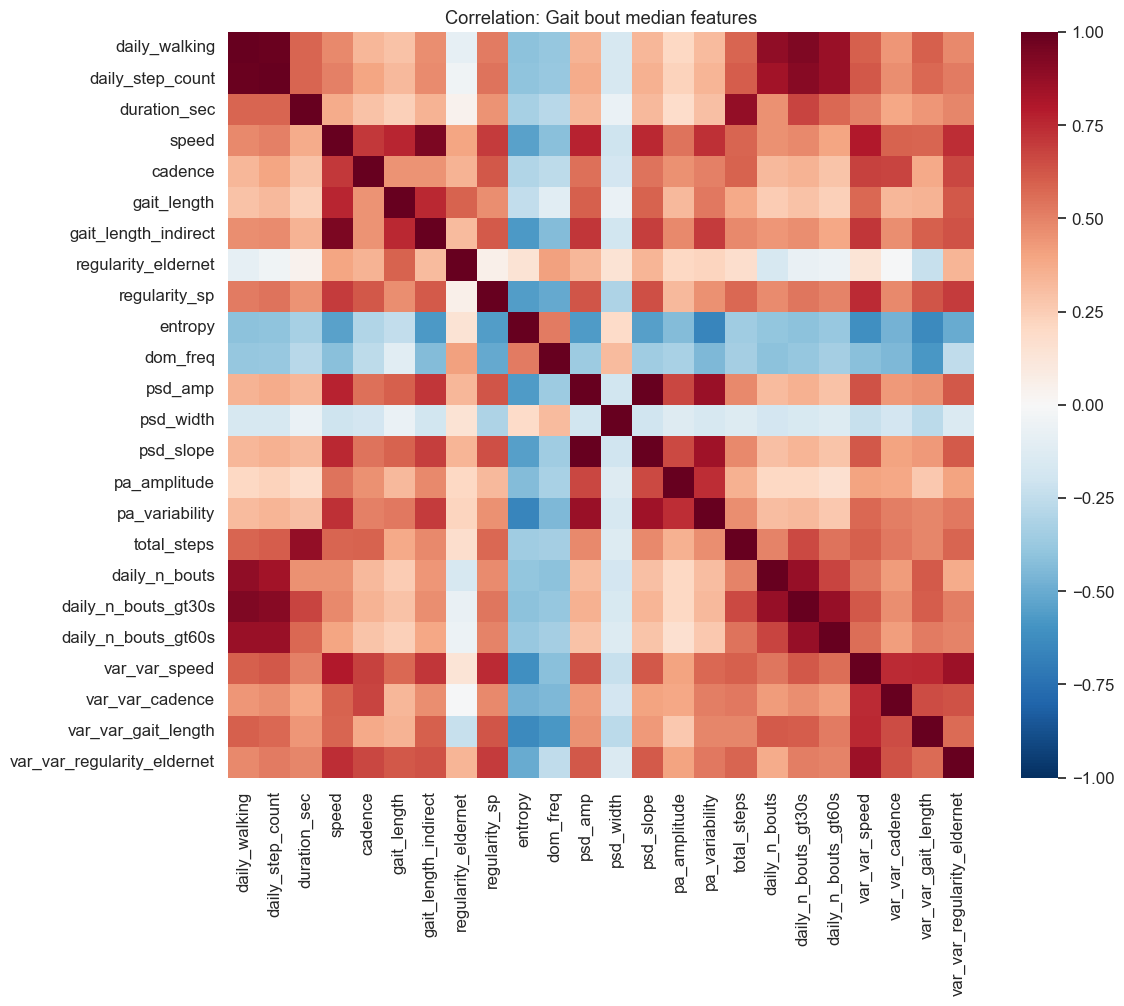

In [30]:
# Correlation heatmap: gait bout median features
gait_median_cols = [c for c in gait_bout_cols if '_median' in c]
corr_gait = df[gait_median_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_gait, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=[c.replace('bout_','').replace('_median','') for c in gait_median_cols],
            yticklabels=[c.replace('bout_','').replace('_median','') for c in gait_median_cols],
            ax=ax, square=True)
ax.set_title('Correlation: Gait bout median features')
plt.tight_layout()
plt.show()

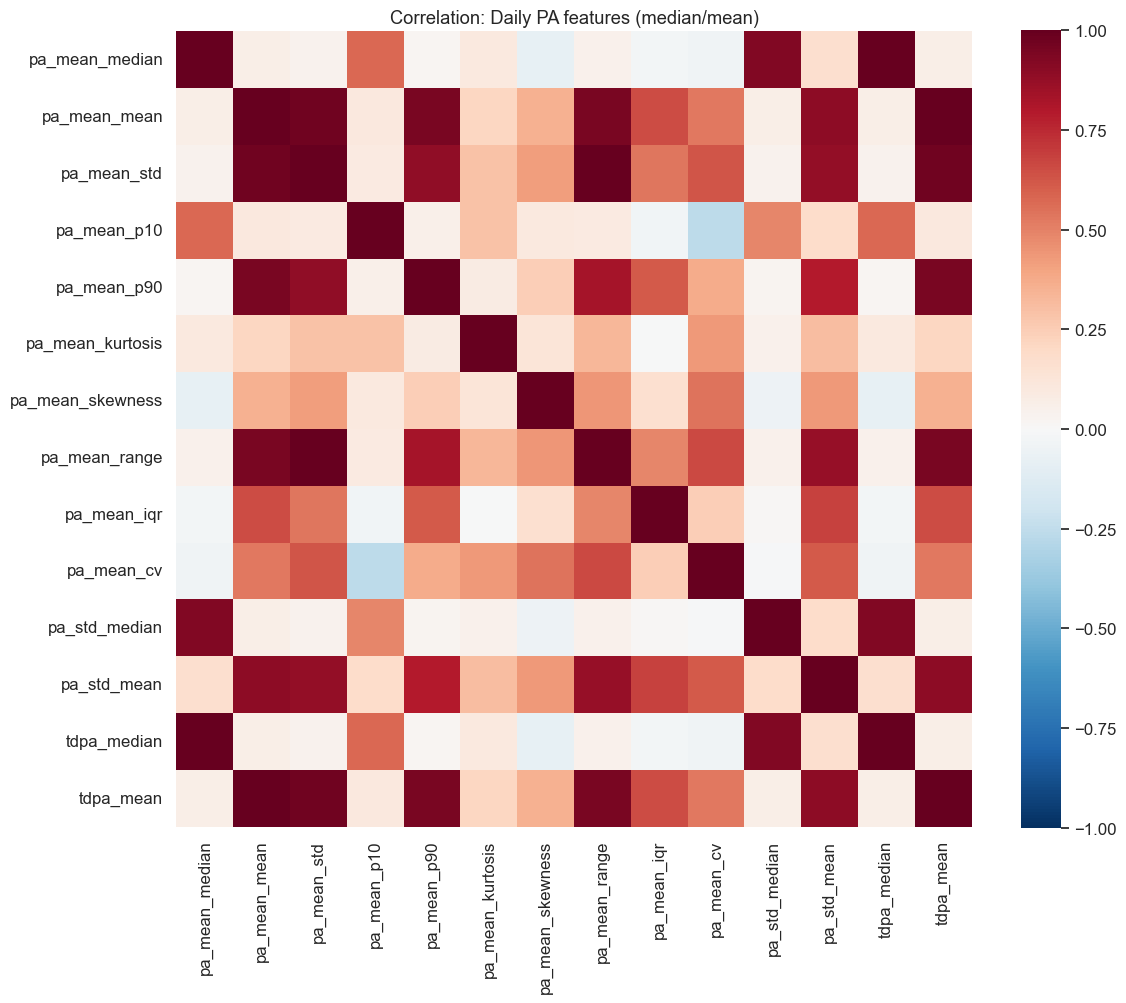

In [31]:
# Correlation heatmap: Daily PA median/mean features
pa_key = [c for c in daily_pa_cols if '_median' in c or '_mean' in c]
corr_pa = df[pa_key].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_pa, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=[c.replace('daily_','') for c in pa_key],
            yticklabels=[c.replace('daily_','') for c in pa_key],
            ax=ax, square=True)
ax.set_title('Correlation: Daily PA features (median/mean)')
plt.tight_layout()
plt.show()

## 8. Feature–outcome associations: Binary outcomes

In [32]:
def top_features_by_effect_size(df, feature_cols, outcome_col, n_top=15):
    """Compute Cohen's d for each feature vs binary outcome, return top N."""
    results = []
    mask = df[outcome_col].notna()
    grp0 = df.loc[mask & (df[outcome_col] == 0)]
    grp1 = df.loc[mask & (df[outcome_col] == 1)]
    for col in feature_cols:
        v0 = grp0[col].dropna()
        v1 = grp1[col].dropna()
        if len(v0) < 10 or len(v1) < 10:
            continue
        pooled_std = np.sqrt(((len(v0)-1)*v0.std()**2 + (len(v1)-1)*v1.std()**2) / (len(v0)+len(v1)-2))
        if pooled_std == 0:
            continue
        d = (v1.mean() - v0.mean()) / pooled_std
        _, p = stats.mannwhitneyu(v0, v1, alternative='two-sided')
        results.append({'feature': col, 'cohens_d': d, 'abs_d': abs(d), 'p_value': p,
                        'mean_0': v0.mean(), 'mean_1': v1.mean()})
    return pd.DataFrame(results).sort_values('abs_d', ascending=False).head(n_top)

print('Top features by Cohen\'s d for each binary outcome:')

Top features by Cohen's d for each binary outcome:


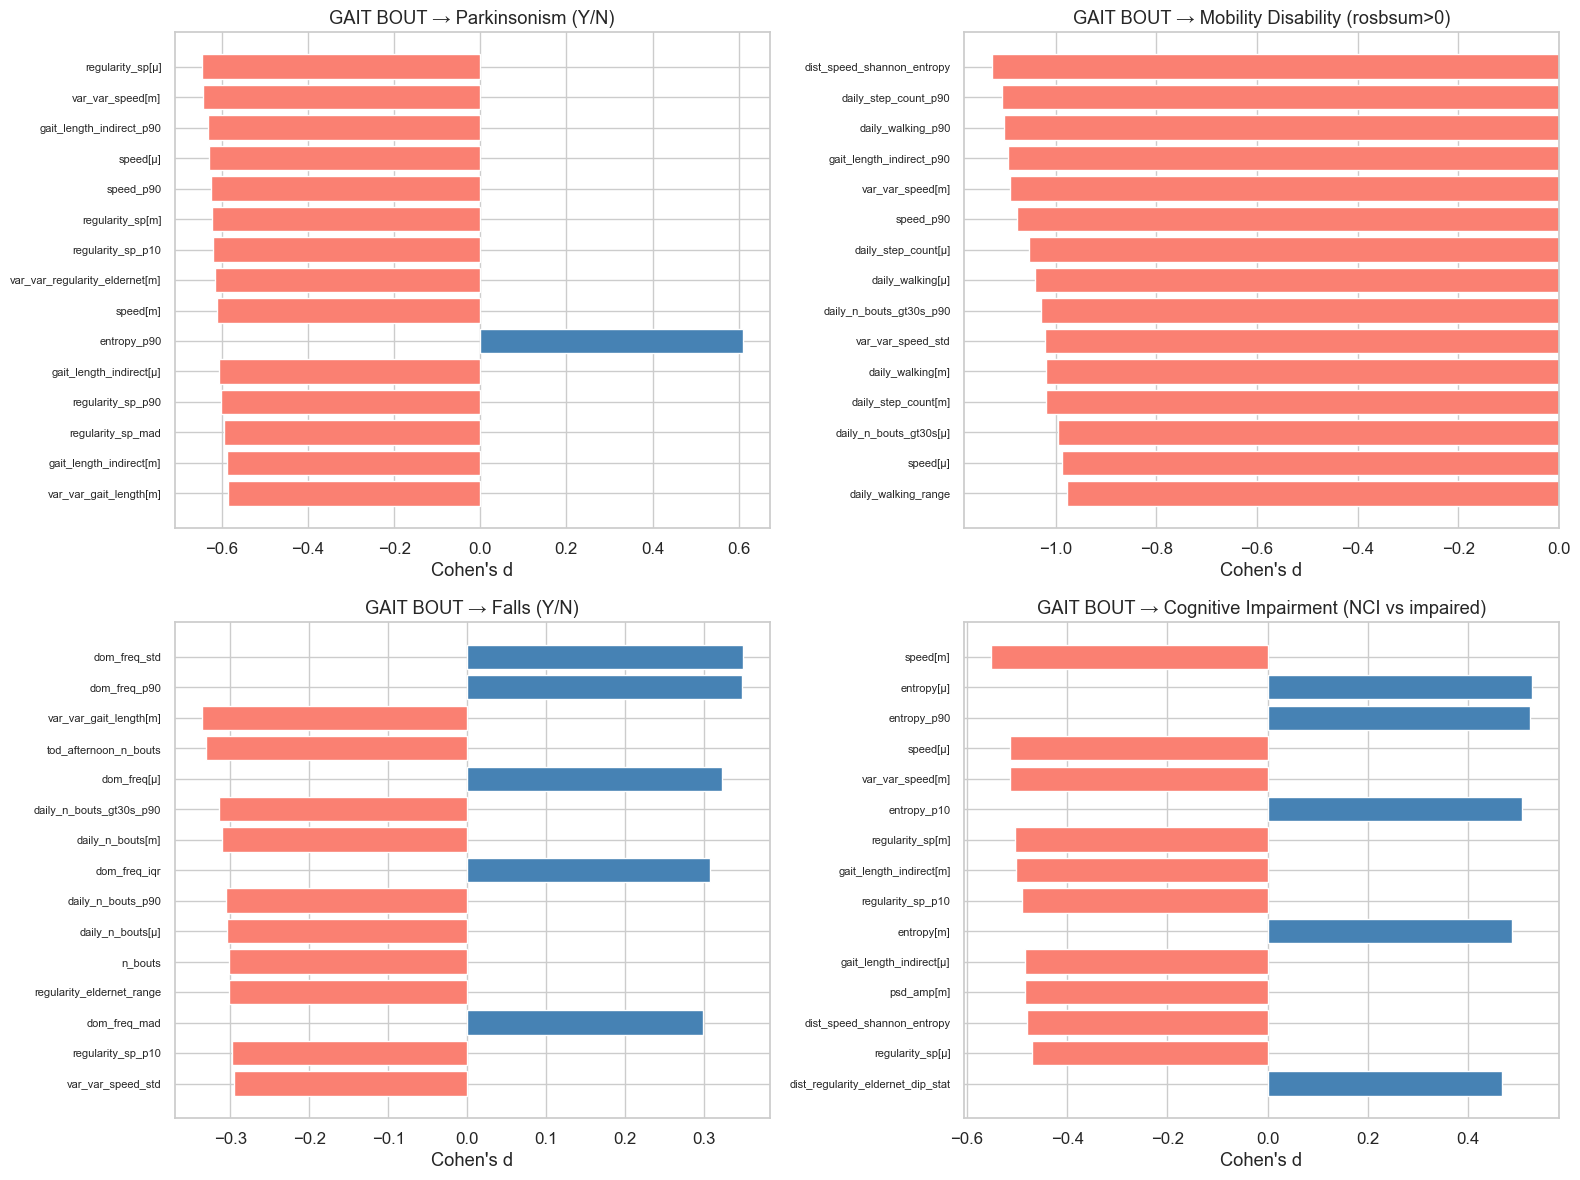

In [33]:
# Gait bout features vs binary outcomes
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, (outcome, label) in zip(axes.flat, binary_outcomes.items()):
    top = top_features_by_effect_size(df, gait_bout_cols, outcome, n_top=15)
    if len(top) == 0:
        ax.set_title(f'{label} — insufficient data')
        continue
    colors = ['salmon' if d < 0 else 'steelblue' for d in top['cohens_d']]
    ax.barh(range(len(top)), top['cohens_d'].values, color=colors)
    ax.set_yticks(range(len(top)))
    short_names = [f.replace('bout_','').replace('_median','[m]').replace('_mean','[μ]') for f in top['feature']]
    ax.set_yticklabels(short_names, fontsize=8)
    ax.set_xlabel("Cohen's d")
    ax.set_title(f'GAIT BOUT → {label}')
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

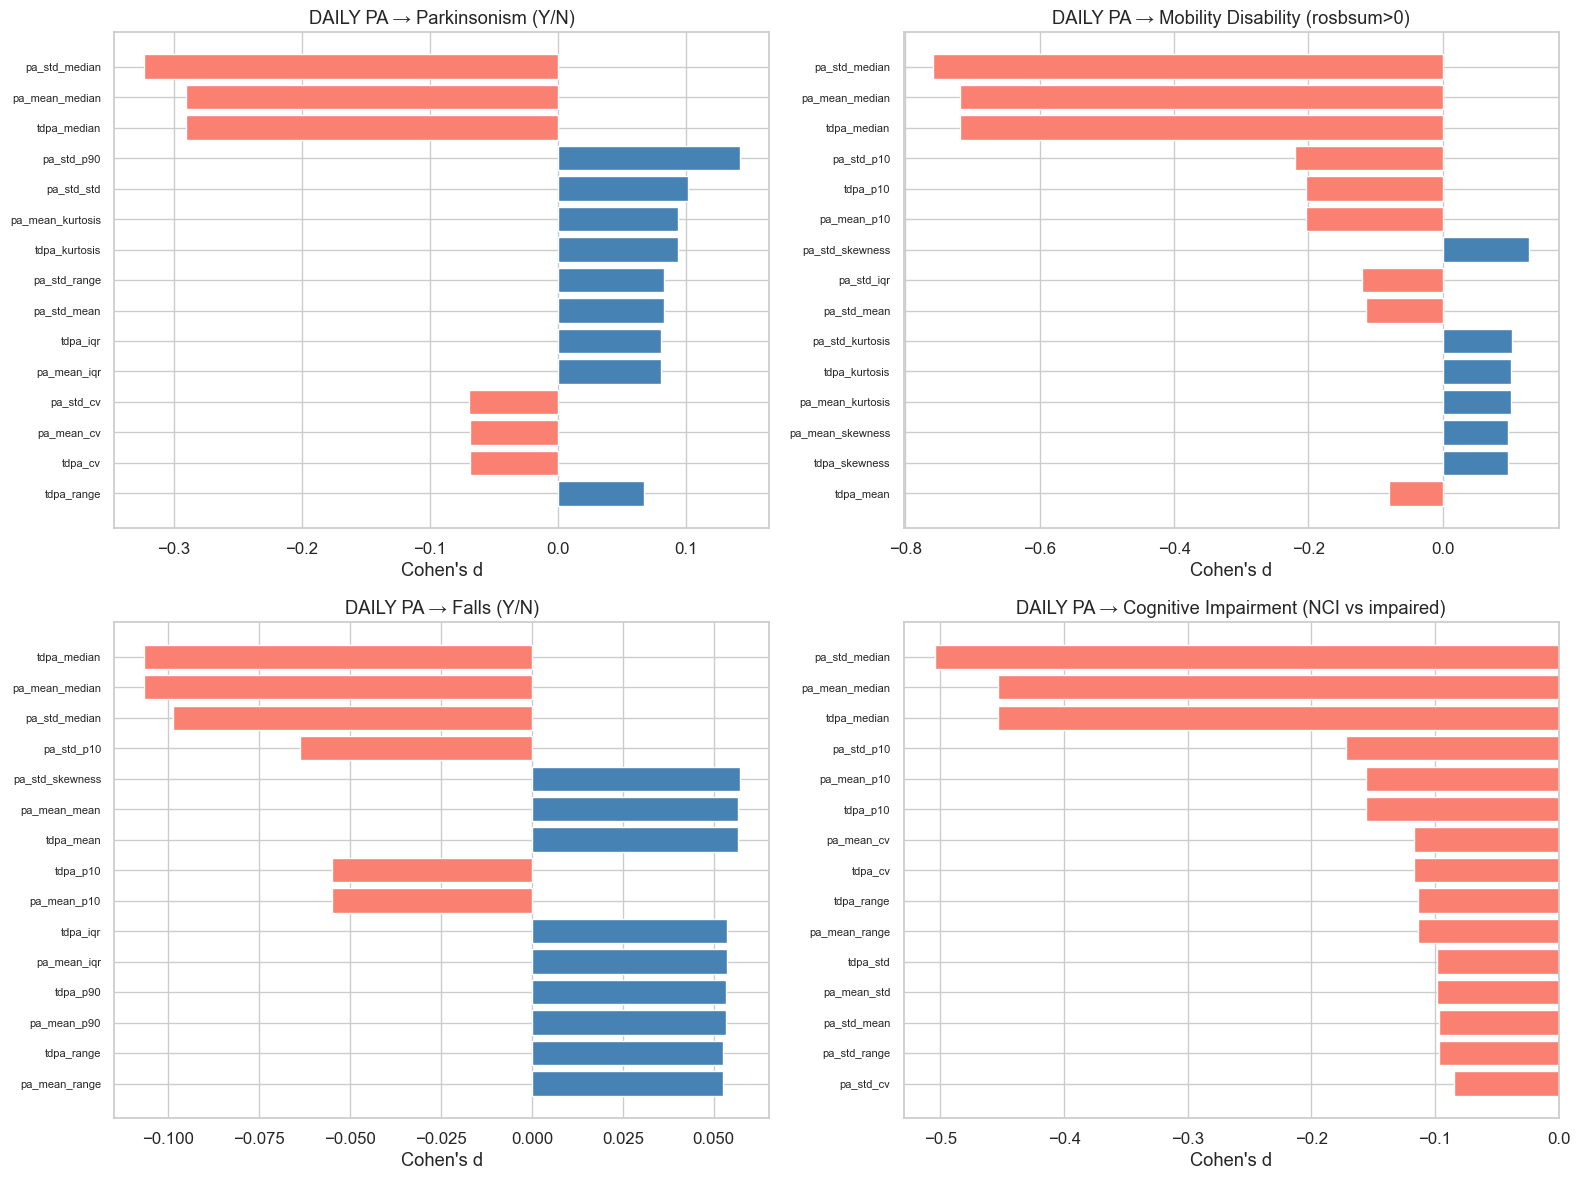

In [34]:
# Daily PA features vs binary outcomes
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, (outcome, label) in zip(axes.flat, binary_outcomes.items()):
    top = top_features_by_effect_size(df, daily_pa_cols, outcome, n_top=15)
    if len(top) == 0:
        ax.set_title(f'{label} — insufficient data')
        continue
    colors = ['salmon' if d < 0 else 'steelblue' for d in top['cohens_d']]
    ax.barh(range(len(top)), top['cohens_d'].values, color=colors)
    ax.set_yticks(range(len(top)))
    short_names = [f.replace('daily_','') for f in top['feature']]
    ax.set_yticklabels(short_names, fontsize=8)
    ax.set_xlabel("Cohen's d")
    ax.set_title(f'DAILY PA → {label}')
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Feature–outcome associations: Continuous outcomes

In [35]:
def top_features_by_correlation(df, feature_cols, outcome_col, n_top=15):
    """Spearman correlation between features and continuous outcome."""
    results = []
    mask = df[outcome_col].notna()
    for col in feature_cols:
        valid = mask & df[col].notna()
        if valid.sum() < 30:
            continue
        rho, p = stats.spearmanr(df.loc[valid, col], df.loc[valid, outcome_col])
        results.append({'feature': col, 'spearman_r': rho, 'abs_r': abs(rho), 'p_value': p})
    return pd.DataFrame(results).sort_values('abs_r', ascending=False).head(n_top)

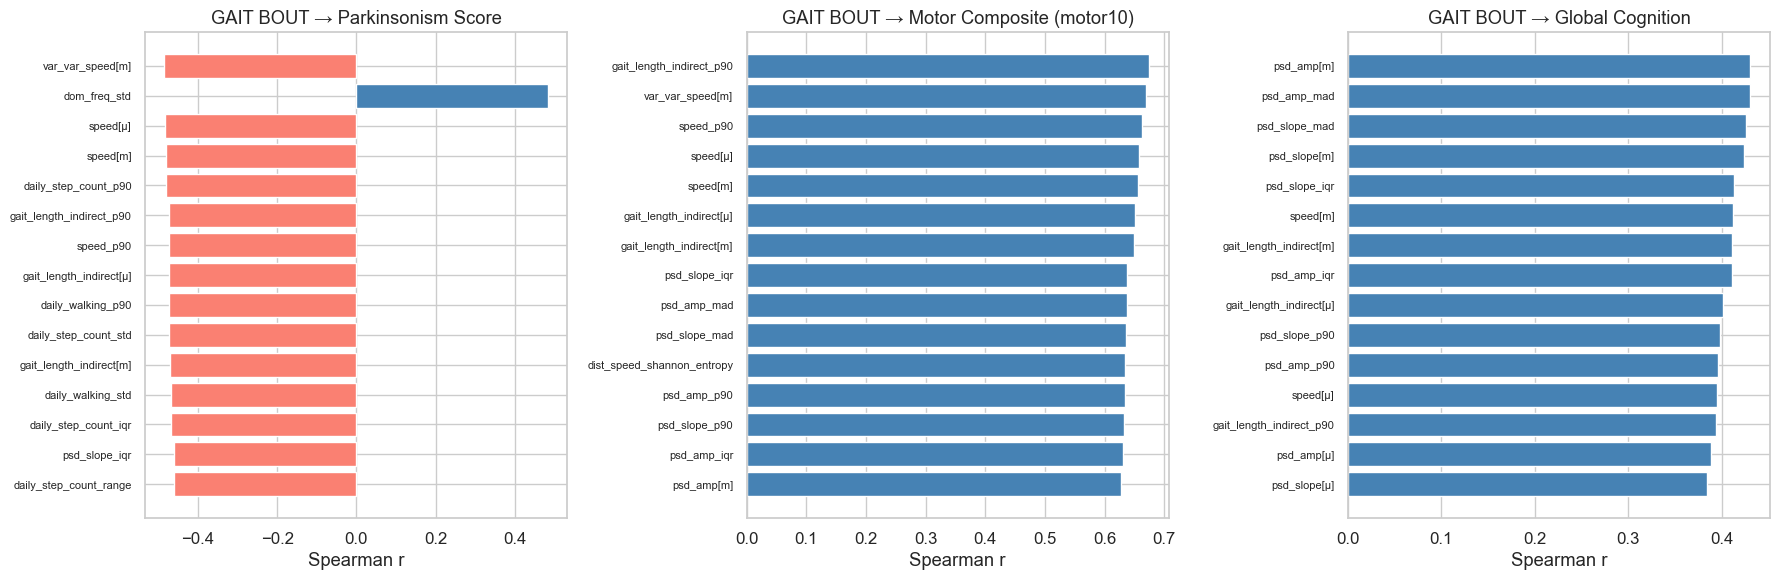

In [36]:
# Gait bout features vs continuous outcomes
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (outcome, label) in zip(axes, continuous_outcomes.items()):
    top = top_features_by_correlation(df, gait_bout_cols, outcome, n_top=15)
    if len(top) == 0:
        ax.set_title(f'{label} — insufficient data')
        continue
    colors = ['salmon' if r < 0 else 'steelblue' for r in top['spearman_r']]
    ax.barh(range(len(top)), top['spearman_r'].values, color=colors)
    ax.set_yticks(range(len(top)))
    short_names = [f.replace('bout_','').replace('_median','[m]').replace('_mean','[μ]') for f in top['feature']]
    ax.set_yticklabels(short_names, fontsize=8)
    ax.set_xlabel('Spearman r')
    ax.set_title(f'GAIT BOUT → {label}')
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

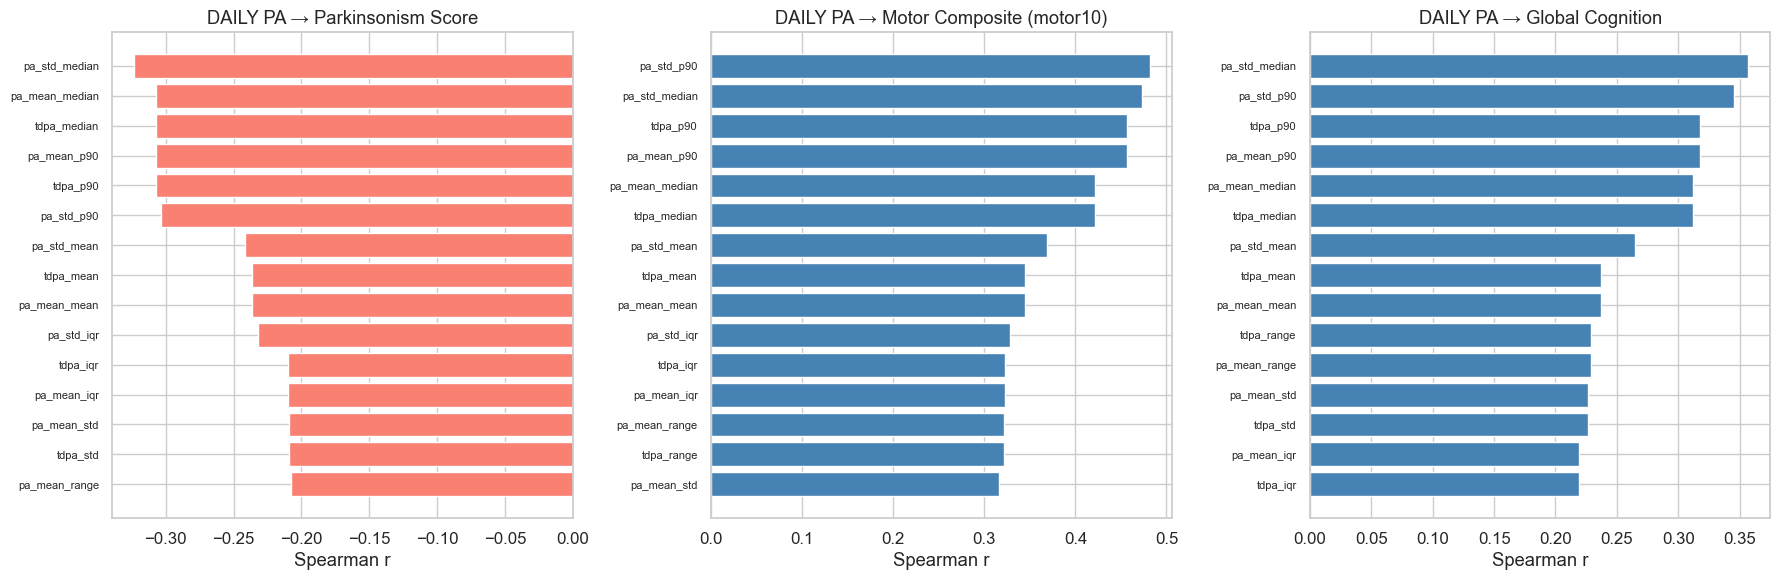

In [37]:
# Daily PA features vs continuous outcomes
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (outcome, label) in zip(axes, continuous_outcomes.items()):
    top = top_features_by_correlation(df, daily_pa_cols, outcome, n_top=15)
    if len(top) == 0:
        ax.set_title(f'{label} — insufficient data')
        continue
    colors = ['salmon' if r < 0 else 'steelblue' for r in top['spearman_r']]
    ax.barh(range(len(top)), top['spearman_r'].values, color=colors)
    ax.set_yticks(range(len(top)))
    short_names = [f.replace('daily_','') for f in top['feature']]
    ax.set_yticklabels(short_names, fontsize=8)
    ax.set_xlabel('Spearman r')
    ax.set_title(f'DAILY PA → {label}')
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Scatter plots: top gait features vs continuous outcomes

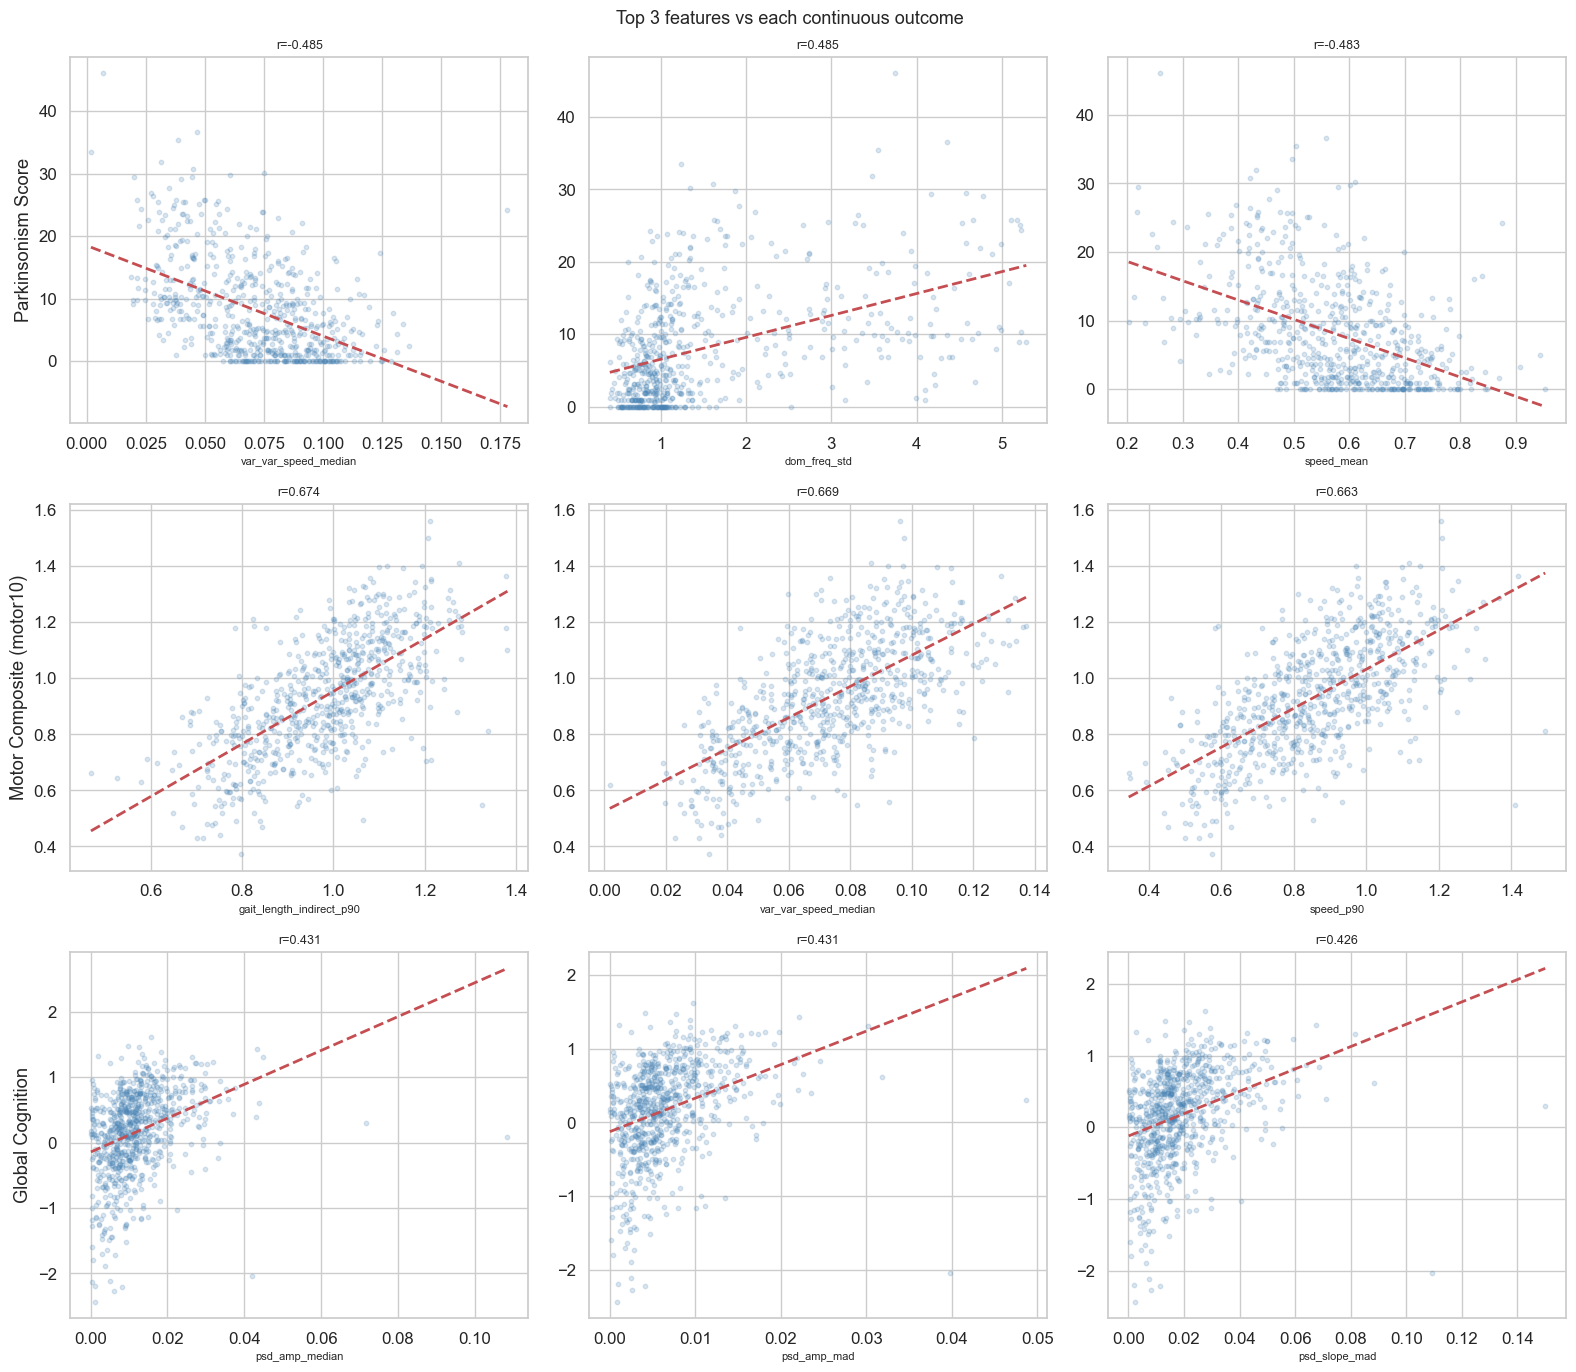

In [38]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for row, (outcome, label) in enumerate(continuous_outcomes.items()):
    top3 = top_features_by_correlation(df, gait_bout_cols + daily_pa_cols, outcome, n_top=3)
    for col_idx, (_, r) in enumerate(top3.iterrows()):
        ax = axes[row, col_idx]
        feat = r['feature']
        valid = df[[feat, outcome]].dropna()
        ax.scatter(valid[feat], valid[outcome], alpha=0.2, s=10, color='steelblue')
        # regression line
        z = np.polyfit(valid[feat], valid[outcome], 1)
        p = np.poly1d(z)
        xr = np.linspace(valid[feat].min(), valid[feat].max(), 100)
        ax.plot(xr, p(xr), 'r--', linewidth=2)
        ax.set_xlabel(feat.replace('bout_','').replace('daily_',''), fontsize=8)
        ax.set_ylabel(label if col_idx == 0 else '')
        ax.set_title(f'r={r["spearman_r"]:.3f}', fontsize=9)
plt.suptitle('Top 3 features vs each continuous outcome', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Box plots: top gait features by binary outcomes

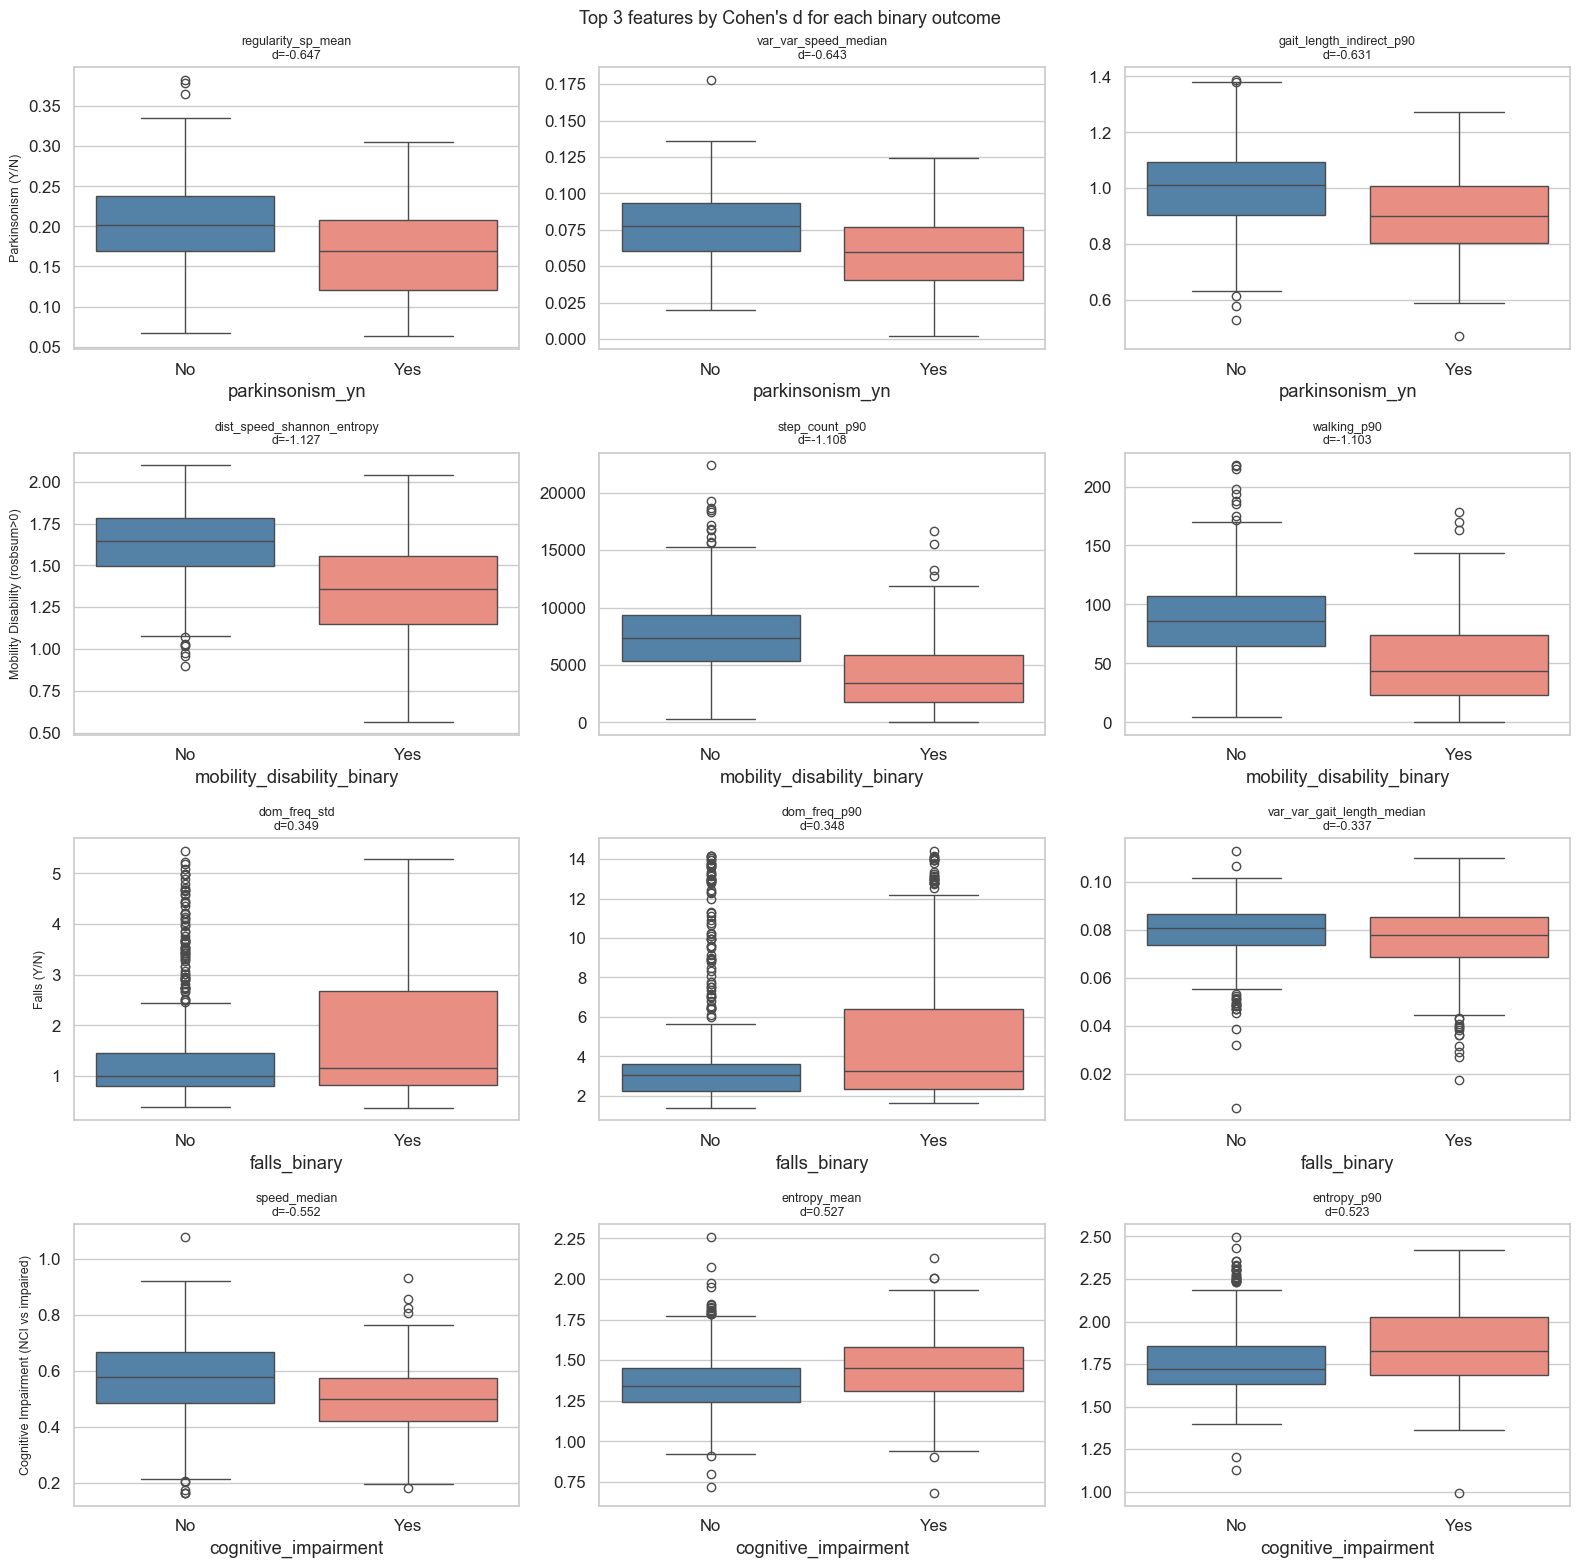

In [39]:
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
for row, (outcome, label) in enumerate(binary_outcomes.items()):
    top3 = top_features_by_effect_size(df, gait_bout_cols + daily_pa_cols, outcome, n_top=3)
    for col_idx, (_, r) in enumerate(top3.iterrows()):
        ax = axes[row, col_idx]
        feat = r['feature']
        plot_df = df[[feat, outcome]].dropna()
        plot_df[outcome] = plot_df[outcome].map({0: 'No', 1: 'Yes'})
        sns.boxplot(data=plot_df, x=outcome, y=feat, ax=ax,
                    palette=['steelblue', 'salmon'])
        ax.set_title(f"{feat.replace('bout_','').replace('daily_','')}\nd={r['cohens_d']:.3f}", fontsize=9)
        if col_idx == 0:
            ax.set_ylabel(label, fontsize=9)
        else:
            ax.set_ylabel('')
plt.suptitle('Top 3 features by Cohen\'s d for each binary outcome', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Gait bout vs Daily PA: comparing discriminative power

In [40]:
# For each binary outcome, compare max |Cohen's d| from each bucket
summary_rows = []
for outcome, label in binary_outcomes.items():
    gait_top = top_features_by_effect_size(df, gait_bout_cols, outcome, n_top=1)
    pa_top = top_features_by_effect_size(df, daily_pa_cols, outcome, n_top=1)
    gait_d = gait_top['abs_d'].values[0] if len(gait_top) > 0 else 0
    pa_d = pa_top['abs_d'].values[0] if len(pa_top) > 0 else 0
    gait_feat = gait_top['feature'].values[0] if len(gait_top) > 0 else ''
    pa_feat = pa_top['feature'].values[0] if len(pa_top) > 0 else ''
    summary_rows.append({'Outcome': label, 'Best Gait d': gait_d, 'Best Gait feat': gait_feat,
                         'Best PA d': pa_d, 'Best PA feat': pa_feat})

for outcome, label in continuous_outcomes.items():
    gait_top = top_features_by_correlation(df, gait_bout_cols, outcome, n_top=1)
    pa_top = top_features_by_correlation(df, daily_pa_cols, outcome, n_top=1)
    gait_r = gait_top['abs_r'].values[0] if len(gait_top) > 0 else 0
    pa_r = pa_top['abs_r'].values[0] if len(pa_top) > 0 else 0
    gait_feat = gait_top['feature'].values[0] if len(gait_top) > 0 else ''
    pa_feat = pa_top['feature'].values[0] if len(pa_top) > 0 else ''
    summary_rows.append({'Outcome': label, 'Best Gait |r|': gait_r, 'Best Gait feat': gait_feat,
                         'Best PA |r|': pa_r, 'Best PA feat': pa_feat})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,Outcome,Best Gait d,Best Gait feat,Best PA d,Best PA feat,Best Gait |r|,Best PA |r|
0,Parkinsonism (Y/N),0.646691,bout_regularity_sp_mean,0.323219,daily_pa_std_median,NaN,NaN
1,Mobility Disability (rosbsum>0),1.126817,dist_speed_shannon_entropy,0.758417,daily_pa_std_median,NaN,NaN
2,Falls (Y/N),0.349104,bout_dom_freq_std,0.106720,tdpa_median,NaN,NaN
3,Cognitive Impairment (NCI vs impaired),0.552348,bout_speed_median,0.504611,daily_pa_std_median,NaN,NaN
4,Parkinsonism Score,NaN,var_var_speed_median,NaN,daily_pa_std_median,0.485036,0.323340
5,Motor Composite (motor10),NaN,bout_gait_length_indirect_p90,NaN,daily_pa_std_p90,0.674130,0.481467
6,Global Cognition,NaN,bout_psd_amp_median,NaN,daily_pa_std_median,0.430762,0.357196


## 13. Feature correlations with demographics (confounders)

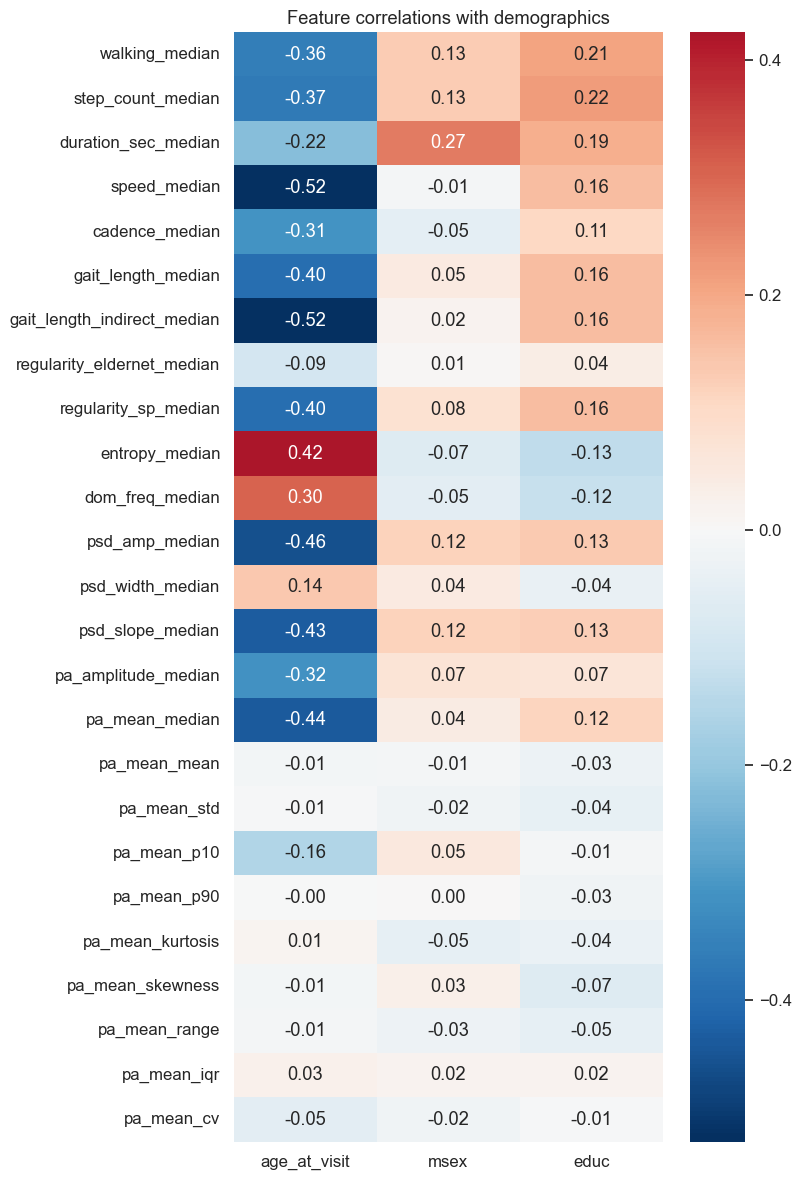

In [41]:
# Check how gait features correlate with age, sex, education
confounders = ['age_at_visit', 'msex', 'educ']
top_gait_feats = [c for c in gait_bout_cols if '_median' in c][:15]
top_pa_feats = [c for c in daily_pa_cols if '_median' in c or '_mean' in c][:10]
all_top = top_gait_feats + top_pa_feats

corr_with_demo = df[all_top + confounders].corr()[confounders].drop(confounders)

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(corr_with_demo, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            yticklabels=[c.replace('bout_','').replace('daily_','') for c in all_top],
            ax=ax)
ax.set_title('Feature correlations with demographics')
plt.tight_layout()
plt.show()

## 14. Principal component analysis: feature buckets

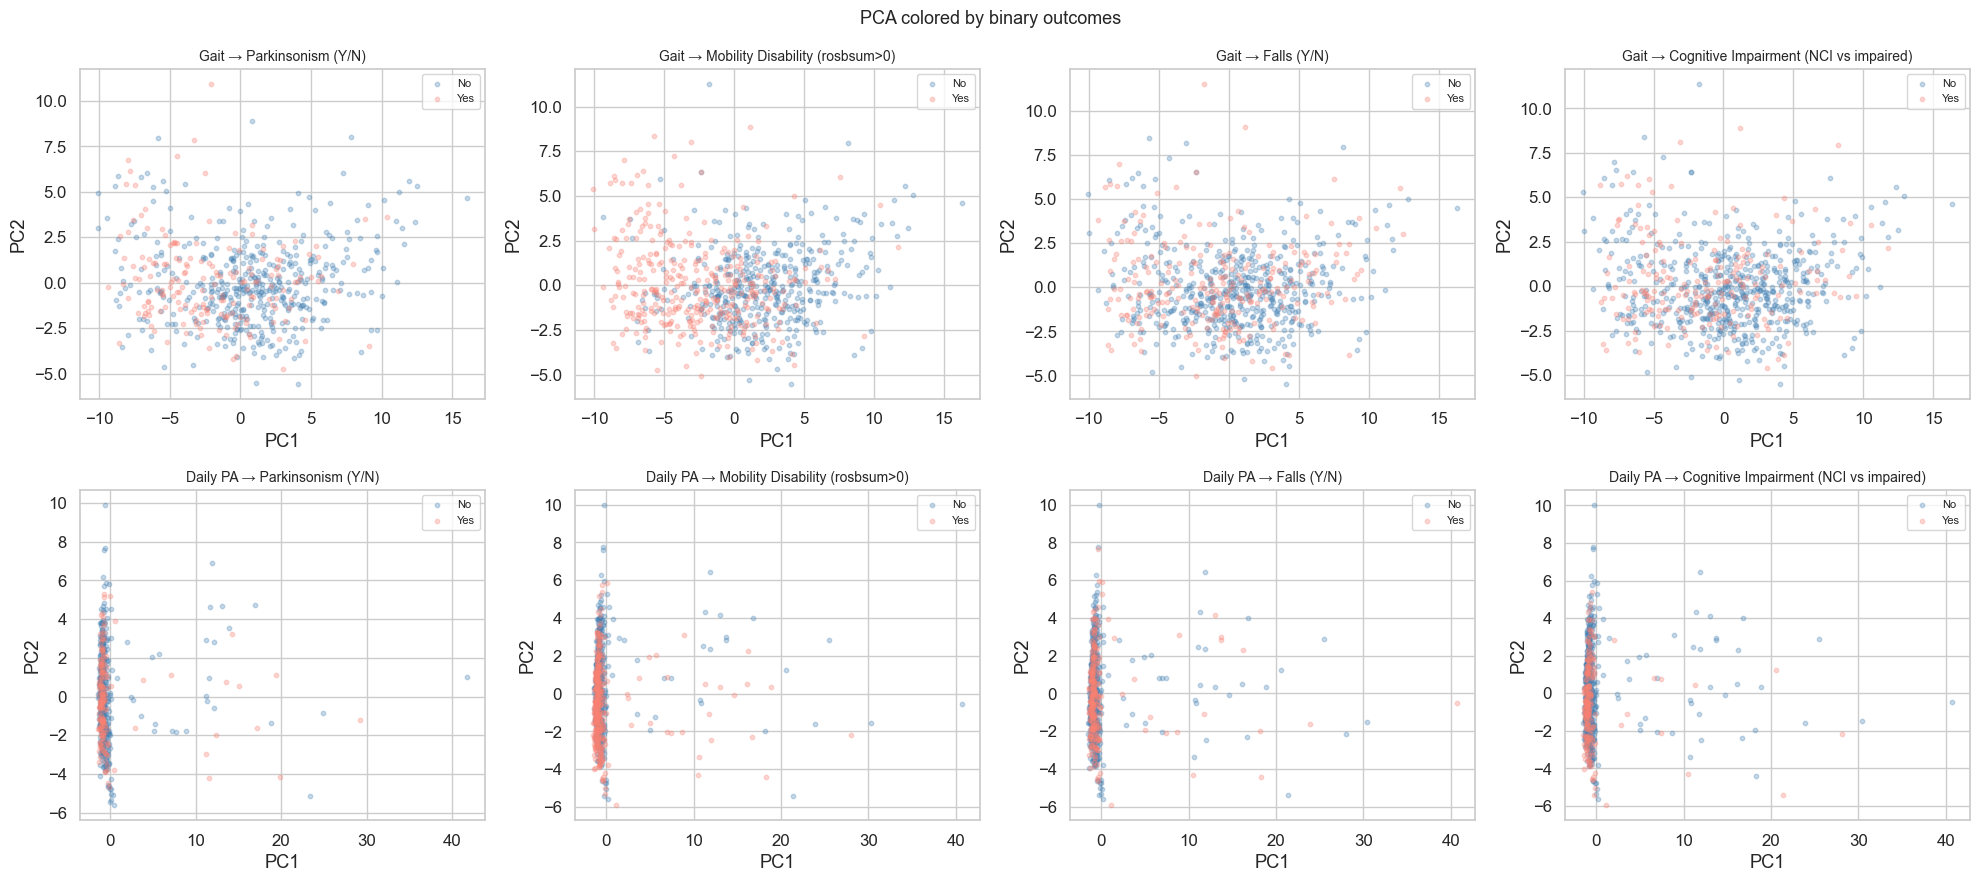

In [42]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def plot_pca_by_outcome(df, feature_cols, outcome_col, outcome_label, bucket_name, ax):
    """PCA scatter colored by binary outcome."""
    sub = df[feature_cols + [outcome_col]].dropna()
    if len(sub) < 30:
        ax.set_title(f'{bucket_name} — insufficient data')
        return
    X = StandardScaler().fit_transform(sub[feature_cols])
    pcs = PCA(n_components=2).fit_transform(X)
    for val, color, label in [(0, 'steelblue', 'No'), (1, 'salmon', 'Yes')]:
        mask = sub[outcome_col].values == val
        ax.scatter(pcs[mask, 0], pcs[mask, 1], c=color, alpha=0.3, s=10, label=label)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'{bucket_name} → {outcome_label}', fontsize=10)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for col_idx, (outcome, label) in enumerate(binary_outcomes.items()):
    plot_pca_by_outcome(df, gait_bout_cols[:50], outcome, label, 'Gait', axes[0, col_idx])
    plot_pca_by_outcome(df, daily_pa_cols, outcome, label, 'Daily PA', axes[1, col_idx])
plt.suptitle('PCA colored by binary outcomes', fontsize=13)
plt.tight_layout()
plt.show()

## 15. Wear days as quality check

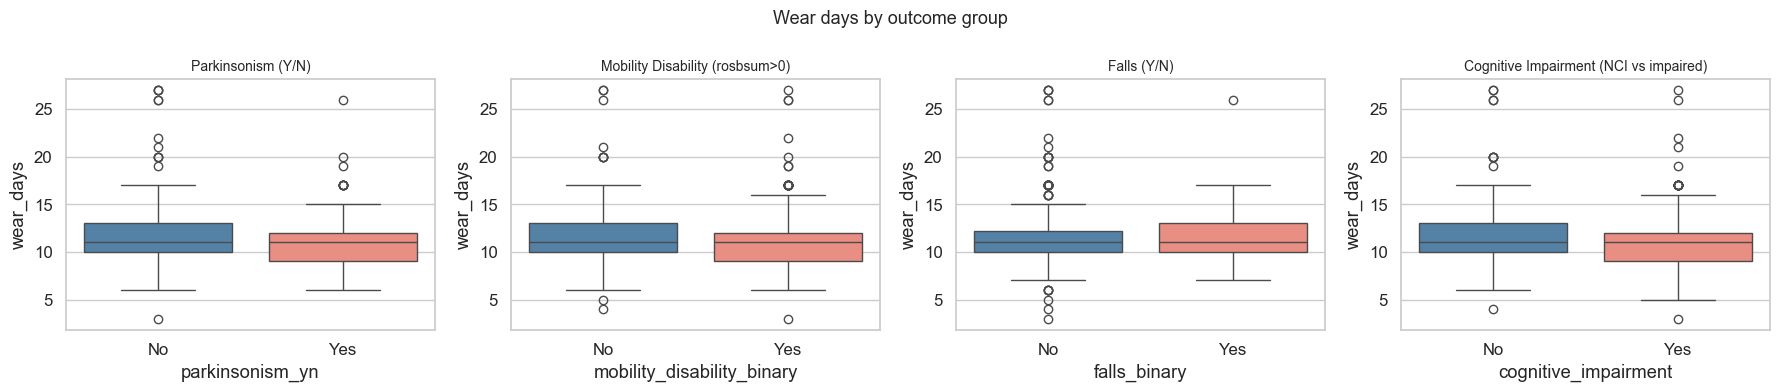

Wear days: mean=11.5, median=11.0, min=3, max=27


In [43]:
# Check if wear days affects outcome distributions
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (outcome, label) in zip(axes, binary_outcomes.items()):
    sub = df[['wear_days', outcome]].dropna()
    sub[outcome] = sub[outcome].map({0: 'No', 1: 'Yes'})
    sns.boxplot(data=sub, x=outcome, y='wear_days', ax=ax, palette=['steelblue', 'salmon'])
    ax.set_title(label, fontsize=10)
plt.suptitle('Wear days by outcome group', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Wear days: mean={df["wear_days"].mean():.1f}, median={df["wear_days"].median():.1f}, '
      f'min={df["wear_days"].min()}, max={df["wear_days"].max()}')

## 16. Summary table

In [44]:
# Final summary
print('=== Dataset Summary ===')
print(f'Total observations: {len(df)}')
print(f'Unique subjects: {df["projid"].nunique()}')
print(f'Gait bout features: {len(gait_bout_cols)}')
print(f'Daily PA features: {len(daily_pa_cols)}')
print()
print('=== Outcome availability ===')
for col, label in {**binary_outcomes, **continuous_outcomes}.items():
    n = df[col].notna().sum()
    print(f'  {label:45s} n={n}')
print()
print('=== Demographics (non-missing) ===')
for col in ['age_at_visit', 'msex', 'educ']:
    print(f'  {col}: n={df[col].notna().sum()}, mean={df[col].mean():.2f}, std={df[col].std():.2f}')

=== Dataset Summary ===
Total observations: 790
Unique subjects: 790
Gait bout features: 290
Daily PA features: 30

=== Outcome availability ===
  Parkinsonism (Y/N)                            n=628
  Mobility Disability (rosbsum>0)               n=785
  Falls (Y/N)                                   n=786
  Cognitive Impairment (NCI vs impaired)        n=786
  Parkinsonism Score                            n=628
  Motor Composite (motor10)                     n=719
  Global Cognition                              n=787

=== Demographics (non-missing) ===
  age_at_visit: n=790, mean=83.33, std=7.38
  msex: n=790, mean=0.23, std=0.42
  educ: n=790, mean=16.07, std=3.10
